In [51]:
#!unzip "/content/data_klasifikasi_batik-20240923T142326Z-001.zip" -d "/content/data_klasifikasi_batikk"

In [52]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os
def view_random_image(target_dir,target_class):
  target_folder = target_dir + target_class
  random_image = random.sample(os.listdir(os.path.join(target_dir, target_class)),1)

  img = mpimg.imread(target_folder + "/" + random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis("off")

  print(f"Ukuran gambar:{img.shape}")
  return img

Ukuran gambar:(450, 450, 3)


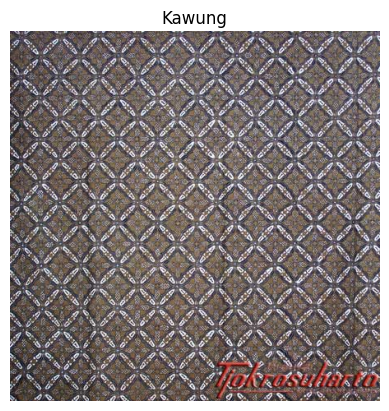

In [53]:
img = view_random_image("/content/data_klasifikasi_batikk/data_klasifikasi_batik/train/","Kawung")

In [54]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint

In [55]:
tf.random.set_seed(46)

In [56]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)

In [57]:
train_dir = "/content/data_klasifikasi_batikk/data_klasifikasi_batik/train"
valid_dir = "/content/data_klasifikasi_batikk/data_klasifikasi_batik/test"

In [58]:
train_data = train_datagen.flow_from_directory(train_dir,
                                               batch_size=16,
                                               target_size=(450, 450),
                                               class_mode="categorical",
                                               shuffle=True)
valid_data = valid_datagen.flow_from_directory(valid_dir,
                                               batch_size=16,
                                               target_size=(450, 450),
                                               class_mode="categorical",
                                               shuffle=True)


Found 580 images belonging to 6 classes.
Found 60 images belonging to 6 classes.


In [59]:
model_1 = Sequential([
                      Conv2D(10,3,activation='relu'),
                      MaxPool2D(2),
                      Conv2D(10,3,activation='relu'),
                      MaxPool2D(2),
                      Flatten(),
                      Dense(6, activation= "softmax")
                      ])

In [60]:
model_1.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])

In [61]:
history_1 = model_1.fit(train_data,
                        epochs=10,
                        validation_data=valid_data,)

Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.2120 - loss: 6.5961 - val_accuracy: 0.2167 - val_loss: 1.8141
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.5518 - loss: 1.5083 - val_accuracy: 0.1833 - val_loss: 1.7827
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 132ms/step - accuracy: 0.6496 - loss: 1.1540 - val_accuracy: 0.3833 - val_loss: 1.7831
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.7949 - loss: 0.8258 - val_accuracy: 0.4167 - val_loss: 1.6675
Epoch 5/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8362 - loss: 0.6694 - val_accuracy: 0.3667 - val_loss: 2.0328
Epoch 6/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.8562 - loss: 0.5300 - val_accuracy: 0.4000 - val_loss: 1.8742
Epoch 7/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.8688 - loss: 0.4787 - val_accuracy: 0.3667 - val_loss: 2.0953
Epoch 8/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 128ms/step - accuracy: 0.9039 - loss: 0.3667 - val_accuracy:

In [62]:
def plot_loss_curves(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']

    epochs = range(len(history.history['loss']))

    #plot
    plt.plot(epochs,loss,label = 'training_loss')
    plt.plot(epochs,val_loss,label = 'val_loss')
    plt.title("Loss")
    plt.xlabel("epochs")
    plt.legend()

    plt.figure()
    plt.plot(epochs,accuracy,label = 'training_acc')
    plt.plot(epochs,val_accuracy,label = 'val_acc')
    plt.title("Accuracy")
    plt.xlabel("epochs")
    plt.legend()

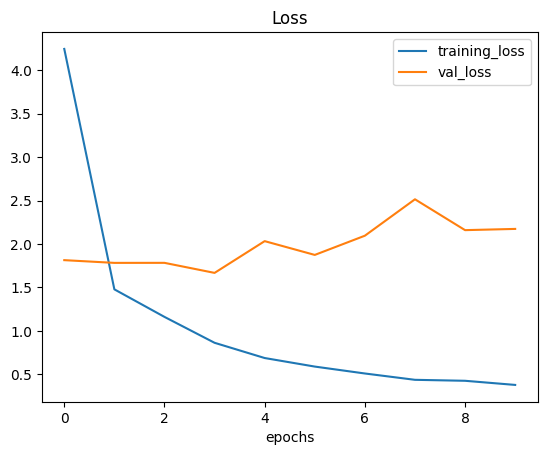

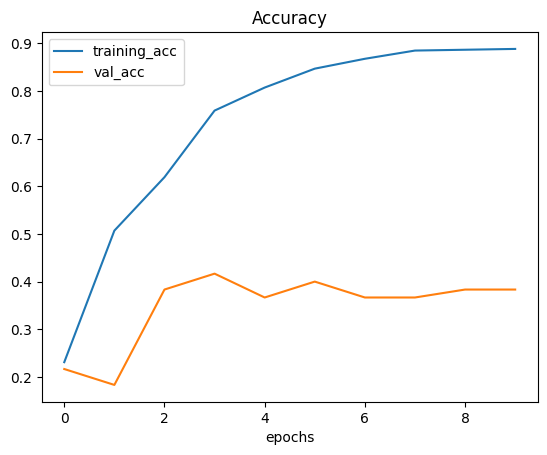

In [63]:
plot_loss_curves(history_1)

In [64]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentasi data untuk memperkaya variasi dataset
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  # Putar gambar untuk augmentasi
    width_shift_range=0.2,  # Pindahkan gambar secara horizontal
    height_shift_range=0.2,  # Pindahkan gambar secara vertikal
    shear_range=0.15,  # Distorsi gambar
    zoom_range=0.3,  # Zoom untuk augmentasi
    horizontal_flip=True,  # Flip gambar secara horizontal
    fill_mode='nearest'  # Cara mengisi ulang piksel yang hilang setelah augmentasi
)

valid_datagen = ImageDataGenerator(rescale=1./255)


In [65]:
train_data_augmented = train_datagen.flow_from_directory(train_dir,
                                                        batch_size=32,
                                                        target_size=(450,450),
                                                        class_mode="categorical",
                                                        shuffle=True)

Found 580 images belonging to 6 classes.


In [66]:
from tensorflow.keras.layers import BatchNormalization, Dropout

model_2 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(450, 450, 3)),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.25),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.4),

    # Tambahkan layer konvolusi tambahan
    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.4),

    Conv2D(512, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.5),

    Flatten(),

    Dense(256, activation='relu'),  # Tambah unit dalam Dense layer
    BatchNormalization(),
    Dropout(0.5),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(6, activation='softmax')  # Sesuaikan dengan jumlah kelas
])


model_2.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])


history_2 = model_2.fit(train_data_augmented,
                        epochs=10,
                        validation_data=valid_data)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.2153 - loss: 2.8787 - val_accuracy: 0.1667 - val_loss: 2.8005
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2671 - loss: 2.5452 - val_accuracy: 0.1667 - val_loss: 3.0807
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.2511 - loss: 2.4767 - val_accuracy: 0.1667 - val_loss: 3.6263
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 986ms/step - accuracy: 0.2735 - loss: 2.3774 - val_accuracy: 0.1667 - val_loss: 6.9093
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.2854 - loss: 2.4155 - val_accuracy: 0.1667 - val_loss: 2.3232
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.2979 - loss: 2.0233 - val_accuracy: 0.2333 - val_loss: 3.0307
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.3520 - loss: 2.0162 - val_accuracy: 0.1833 - val_loss: 3.2044
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.3024 - loss: 2.1506 - val_accuracy: 0.1667 - val_loss: 2.5484


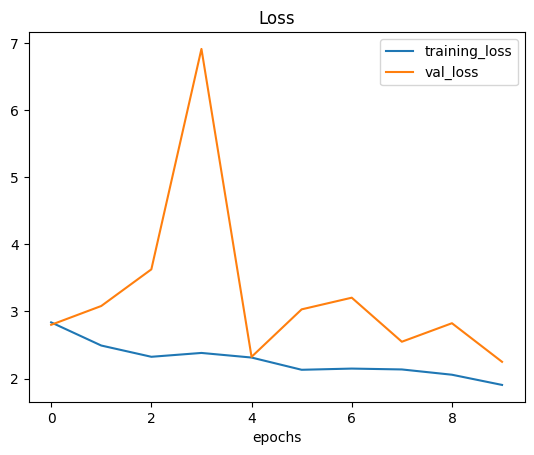

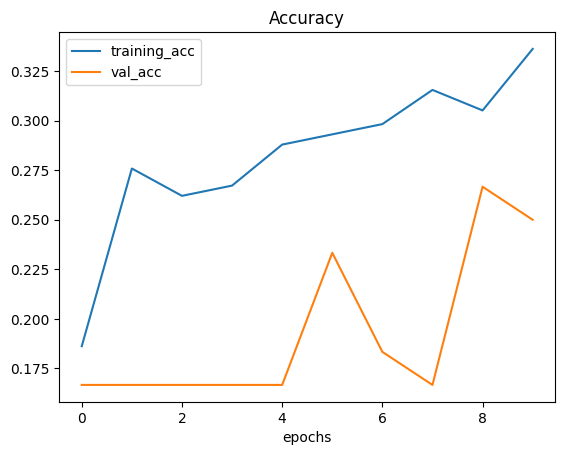

In [67]:
plot_loss_curves(history_2)

In [68]:
import tensorflow as tf
base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(450,450,3),
                                                           include_top=False,
                                                           weights='imagenet'
                                                          )

<ipython-input-68-f13d09799480>:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.mobilenet_v2.MobileNetV2(input_shape=(450,450,3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [69]:
base_model.trainable = False

In [70]:
global_average_layer = tf.keras.layers.GlobalAveragePooling2D()
prediction_layer = Dense(6, activation='softmax')  # Sesuaikan dengan jumlah kelas

inputs = tf.keras.Input(shape=(450, 450, 3))
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = Dropout(0.2)(x)
outputs = prediction_layer(x)

model = tf.keras.Model(inputs,outputs)

In [71]:
model.compile(loss="categorical_crossentropy",
                optimizer=Adam(),
                metrics=['accuracy'])

history = model.fit(train_data_augmented,
                    epochs=10,
                    validation_data=valid_data)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.2776 - loss: 1.7403 - val_accuracy: 0.3500 - val_loss: 1.9223
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 893ms/step - accuracy: 0.4490 - loss: 1.4793 - val_accuracy: 0.4333 - val_loss: 1.6511
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 894ms/step - accuracy: 0.5427 - loss: 1.2574 - val_accuracy: 0.4500 - val_loss: 1.5214
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.5341 - loss: 1.2669 - val_accuracy: 0.4167 - val_loss: 1.6000
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 999ms/step - accuracy: 0.5791 - loss: 1.1555 - val_accuracy: 0.4000 - val_loss: 1.5109
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 954ms/step - accuracy: 0.5858 - loss: 1.1033 - val_accuracy: 0.4167 - val_loss: 1.5597
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 899ms/step - accuracy: 0.5766 - loss: 1.0799 - val_accuracy: 0.4833 - val_loss: 1.4545
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 28s 904ms/step - accuracy: 0.6547 - loss: 0.9618 - val_accuracy: 

In [72]:
# Fine-tuning setelah beberapa epoch
base_model.trainable = True

In [73]:
# Membekukan beberapa lapisan awal agar tidak terlalu overfit
for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(loss="categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(1e-5),  # Learning rate yang lebih kecil
              metrics=['accuracy'])

fine_tune_epochs = 10
total_epochs = 10 + fine_tune_epochs

history_fine = model.fit(train_data,
                         epochs=total_epochs,
                         initial_epoch=history.epoch[-1],
                         validation_data=valid_data)

Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 41s 509ms/step - accuracy: 0.4273 - loss: 1.5311 - val_accuracy: 0.4333 - val_loss: 1.6164
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 18s 168ms/step - accuracy: 0.5232 - loss: 1.3366 - val_accuracy: 0.4167 - val_loss: 1.6453
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step - accuracy: 0.6076 - loss: 1.1262 - val_accuracy: 0.4333 - val_loss: 1.6808
Epoch 13/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.6318 - loss: 0.9943 - val_accuracy: 0.4500 - val_loss: 1.6986
Epoch 14/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.6742 - loss: 0.9066 - val_accuracy: 0.4333 - val_loss: 1.7119
Epoch 15/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.6586 - loss: 0.9459 - val_accuracy: 0.4333 - val_loss: 1.7283
Epoch 16/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - accuracy: 0.6826 - loss: 0.8300 - val_accuracy: 0.4333 - val_loss: 1.7284
Epoch 17/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 141ms/step - accuracy: 0.7443 - loss: 0.7460 - val_

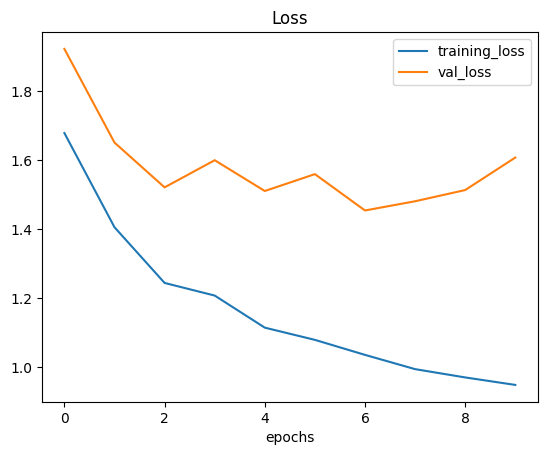

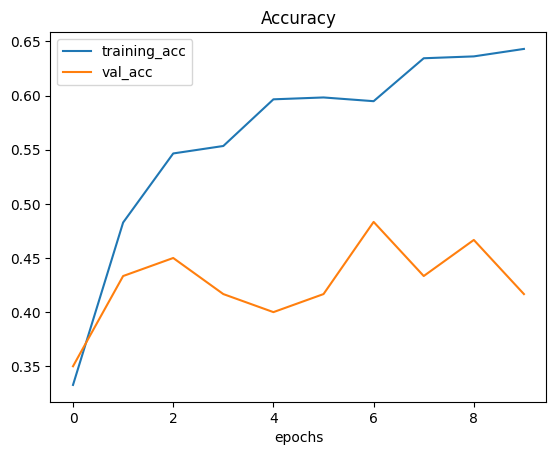

In [74]:
plot_loss_curves(history)